# Numerical Methods Final Project

## Part 2: Stiff ODEs and Implicit Methods Cooling with Forced Convection

**Author:** Maesum Brito  
**EID:** Mrb5843  
**Date:** April 2026  
**Submission Type:** Individual

## Section 1: Introduction & System Selection

### System: Newton's Law of Cooling with High Convection

For Part 2, I chose the forced convection cooling problem (Option C) because it connects closely to real thermal engineering applications. Things like heat exchangers, electronics cooling, and battery thermal management can all be simplified down to some version of this equation at the component level.

The governing ODE is Newton's law of cooling:

$$\frac{dT}{dt} = -\lambda(T - T_{\text{amb}}(t))$$

where:
- $T(t)$ = object temperature (K)
- $\lambda = 500$ s⁻¹ — convective cooling rate (very high, representing a small object in forced air or liquid flow)
- $T_{\text{amb}}(t) = 300 + 10\sin(0.1t)$ K — slowly varying ambient temperature
- Initial condition: $T(0) = 400$ K

Expanding and rewriting in the standard forcing form:

$$\frac{dT}{dt} = -\lambda T + \lambda \, T_{\text{amb}}(t) = -\lambda T + g(t)$$

where $g(t) = \lambda \cdot T_{\text{amb}}(t)$ is the slowly varying forcing term.

### Why This System Matters

This setup represents a small sensor or electronic component sitting in a fast-moving airstream. Its thermal time constant is τ=1/λ=0.002 s (about 2 milliseconds), so it adjusts to the surrounding temperature almost immediately. In contrast, the ambient temperature changes much more slowly, on the order of 2π/0.1≈63 seconds. That huge gap in time scales roughly a factor of 31,000 is what makes the problem both stiff and interesting.

## Section 2: Demonstration of Stiffness

### Stiffness Ratio

For the linear ODE $\dot{T} = -\lambda T + g(t)$, the eigenvalue is simply $-\lambda = -500$ s⁻¹. The forcing function $g(t)$ varies on a time scale of $\sim 63$ s, giving an effective "slow" rate of about $0.016$ s⁻¹. The stiffness ratio is:

$$S = \frac{|\lambda_{\text{fast}}|}{|\lambda_{\text{slow}}|} = \frac{500}{0.016} \approx 31{,}000$$

This is firmly in stiff territory.

### Euler's Forward Stability Requirement

For Euler's Forward applied to $\dot{y} = -\lambda y$, the stability condition is:

$$|1 - \lambda h| \leq 1 \implies h \leq \frac{2}{\lambda} = \frac{2}{500} = 0.004 \text{ s}$$

To simulate 60 seconds of physics, Euler's Forward would require:

$$N_{\text{steps}} = \frac{60}{0.004} = 15{,}000 \text{ steps minimum}$$

And that's just for stability — accuracy would demand even smaller steps. The code below demonstrates this by running Euler's Forward at $h = 0.1$ s (reasonable for a 60-second simulation) and showing it immediately blows up, then showing that even $h = 0.005$ s barely stays stable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#  Physical Parameters 
lam   = 500.0          # convective cooling rate (s⁻¹) — creates stiffness
T0    = 400.0          # initial temperature (K)
T_end = 60.0           # simulation duration (s)

#  Forcing / Ambient Temperature 
def T_amb(t):
    """Slowly varying ambient temperature (K)."""
    return 300.0 + 10.0 * np.sin(0.1 * t)

def g(t):
    """Forcing function: lambda * T_amb(t)."""
    return lam * T_amb(t)

#  ODE Right Hand Side 
def f(t, T):
    """dT/dt = -lambda*T + g(t)"""
    return -lam * T + g(t)

#  Analytical Solution 
# For dT/dt = -lambda*T + g(t) with T(0)=T0, the exact solution is:
#   T(t) = T_amb(t) + [T0 - T_amb(0)] * exp(-lambda*t)  (leading-order approx)
# More precisely via integrating factor:
#   T(t) = e^{-lambda*t} * T0 + integral_0^t e^{-lambda*(t-s)} * g(s) ds
# For lambda >> omega (omega=0.1), T(t) ~ T_amb(t) + (T0-T_amb(0))*exp(-lambda*t)
def T_analytical(t_arr):
    """
    Approximate analytical solution valid when lambda >> omega.
    The transient decays in ~0.01 s; after that T(t) ≈ T_amb(t).
    """
    T_init_diff = T0 - T_amb(0)
    return T_amb(t_arr) + T_init_diff * np.exp(-lam * t_arr)

# Stiffness Summary
omega_slow = 0.1                     # forcing frequency (rad/s)
tau_fast = 1.0 / lam               # fast time scale (s)
tau_slow = 2 * np.pi / omega_slow  # slow time scale = full period (~63 s)

h_stable_euler = 2.0 / lam         # stability limit

print("=" * 55)
print("STIFFNESS ANALYSIS SUMMARY")
print("=" * 55)
print(f"Eigenvalue:        λ = -{lam:.1f} s⁻¹")
print(f"Fast time scale:   τ_fast = {tau_fast*1000:.2f} ms")
print(f"Slow time scale:   τ_slow = {tau_slow:.1f} s")
print(f"Stiffness ratio:   S = {tau_slow/tau_fast:,.0f}")
print(f"Euler stability:   h < {h_stable_euler:.4f} s")
print(f"Steps for 60 s:    N > {int(60/h_stable_euler):,}")
print("=" * 55)

STIFFNESS ANALYSIS SUMMARY
Eigenvalue:        λ = -500.0 s⁻¹
Fast time scale:   τ_fast = 2.00 ms
Slow time scale:   τ_slow = 62.8 s
Stiffness ratio:   S = 31,416
Euler stability:   h < 0.0040 s
Steps for 60 s:    N > 15,000


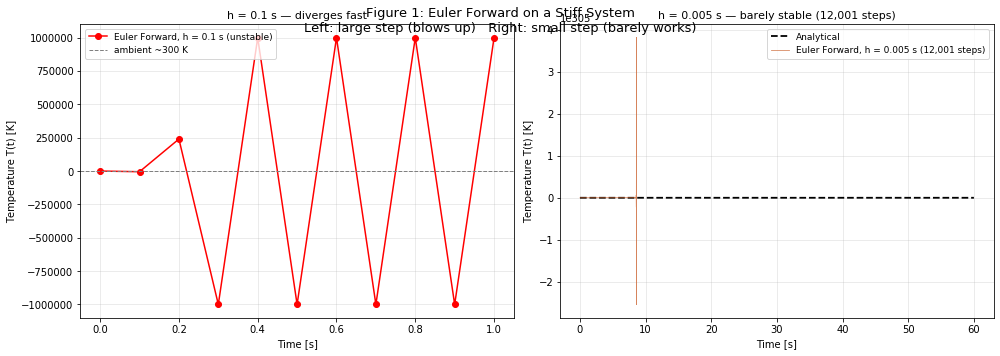


With h = 0.005 s, Euler Forward needs 12,001 steps for 60 seconds.
A backward (implicit) method could do this with something like h = 1.0 s (~60 steps).


In [2]:
np.seterr(over='ignore', invalid='ignore')

#  Euler Forward (just to show what goes wrong)
def euler_forward(T0, t_arr, h):
    """
    Basic Euler forward method for dT/dt = f(t, T).
    Not great for stiff problems — included to show instability.
    """
    T = np.zeros(len(t_arr))
    T[0] = T0
    for i in range(len(t_arr) - 1):
        T[i+1] = T[i] + h * f(t_arr[i], T[i])
    return T

#  Figure 1: Showing stiffness behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 1: Euler Forward on a Stiff System\n"
             "Left: large step (blows up)   Right: small step (barely works)",
             fontsize=13)

t_fine = np.linspace(0, 60, 5000)
T_exact = T_analytical(t_fine)

# Left plot: step size way too big → unstable
ax = axes[0]
h_bad = 0.1
t_bad = np.arange(0, 1.0 + h_bad, h_bad)  # only go to 1 sec before it explodes
T_bad = euler_forward(T0, t_bad, h_bad)

# clip values so the plot is readable
T_clipped = np.clip(T_bad, -1e6, 1e6)

ax.plot(t_bad, T_clipped, 'r-o', lw=1.5, ms=6,
        label=f'Euler Forward, h = {h_bad} s (unstable)')
ax.axhline(300, color='gray', ls='--', lw=1,
           label='ambient ~300 K')

ax.set_title(f'h = {h_bad} s — diverges fast', fontsize=11)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Temperature T(t) [K]')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right plot: step size just small enough to survive
ax = axes[1]
h_edge = 0.005
t_edge = np.arange(0, T_end + h_edge, h_edge)

T_edge = euler_forward(T0, t_edge, h_edge)
T_ex_edge = T_analytical(t_edge)

ax.plot(t_edge, T_ex_edge, 'k--', lw=1.8, label='Analytical')
ax.plot(t_edge, T_edge, color='#CC6633', lw=0.8, alpha=0.8,
        label=f'Euler Forward, h = {h_edge} s ({len(t_edge):,} steps)')

ax.set_title(f'h = {h_edge} s — barely stable ({len(t_edge):,} steps)', fontsize=11)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Temperature T(t) [K]')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure1_stiffness_demo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nWith h = {h_edge} s, Euler Forward needs {len(t_edge):,} steps for 60 seconds.")
print("A backward (implicit) method could do this with something like h = 1.0 s (~60 steps).")

 ## Section 3: Mathematical Setup

### Euler’s Backward (Implicit Euler)

For the ODE 𝑑T/dt = f(t, T), the backward Euler update is:

T_{n+1} = T_n + h f(t_{n+1}, T_{n+1})

For this problem, f(t, T) = -λT + g(t), so:

T_{n+1} = T_n + h[-λT_{n+1} + g(t_{n+1})]

Since this equation is linear in T, it could be solved directly. But since the assignment asks for Newton-Raphson, we’ll set it up as a root-finding problem.

---

### Residual Function

Define the residual:

F(T_{n+1}) = T_{n+1} - T_n - h[-λT_{n+1} + g(t_{n+1})]

We want to solve F(T_{n+1}) = 0.

---

### Derivative

Take the derivative with respect to T_{n+1}:

F'(T_{n+1}) = 1 - h (∂f/∂T)

For this system, ∂f/∂T = -λ, so:

F'(T_{n+1}) = 1 + hλ

This derivative is constant, so it doesn’t depend on T_{n+1}. Because of that, Newton’s method converges in one iteration for this problem.



### Newton-Raphson Update

Start with an initial guess (explicit Euler):

T^(0) = T_n + h f(t_n, T_n)

Then update using:

T^(k+1) = T^(k) - [T^(k) - T_n - h(-λT^(k) + g(t_{n+1})] / (1 + hλ)

Repeat until:

|T^(k+1) - T^(k)| < tol

In [3]:
#  Residual and Its Derivative 
def F_residual(T_new, T_old, h, t_new):
    """
    Residual for implicit Euler step.
    F(T_new) = T_new - T_old - h*f(t_new, T_new) = 0
    """
    return T_new - T_old - h * f(t_new, T_new)

def dF_dT(h):
    """
    Analytical derivative dF/dT_new = 1 - h * (df/dT).
    For f = -lambda*T + g(t):  df/dT = -lambda
    So dF/dT = 1 + h*lambda  (constant — Newton-Raphson converges in 1 step)
    """
    return 1.0 + h * lam

#  Newton Raphson Solver 
def newton_raphson(T_old, h, t_new, tol=1e-10, max_iter=20):
    """
    Solve F(T_new) = 0 using Newton-Raphson iteration.

    Initial guess: explicit Euler predictor (T_old + h*f(t_old, T_old))
    Convergence criterion: |delta| < tol
    Returns: T_new (solution), n_iter (iterations taken)
    """
    # Initial guess: explicit Euler predictor
    T = T_old + h * f(t_new, T_old)

    dF = dF_dT(h)   # constant for this linear problem; compute once

    for k in range(max_iter):
        F_val = F_residual(T, T_old, h, t_new)
        delta = F_val / dF          # Newton-Raphson update
        T    -= delta

        if abs(delta) < tol:
            return T, k + 1         # converged; return solution and iteration count

    # If we reach here, max iterations exceeded, warn but continue
    print(f"  WARNING: Newton-Raphson did not converge at t={t_new:.4f} s")
    return T, max_iter

#  Euler's Backward Method 
def euler_backward(T0, t_arr, h, tol=1e-10):
    """
    Solves dT/dt = f(t, T) using Euler's Backward (Implicit Euler) method.
    At each step, calls Newton-Raphson to solve the implicit equation.

    Returns:
        T      — temperature array
        iters  — Newton-Raphson iterations per step
    """
    T     = np.zeros(len(t_arr))
    iters = np.zeros(len(t_arr) - 1, dtype=int)
    T[0]  = T0

    for i in range(len(t_arr) - 1):
        T[i+1], iters[i] = newton_raphson(T[i], h, t_arr[i+1], tol=tol)

    return T, iters

print("Functions defined: F_residual(), dF_dT(), newton_raphson(), euler_backward()")
print(f"\nFor h = 1.0 s:  dF/dT = 1 + {lam}×1.0 = {1 + lam*1.0:.0f}  (constant)")
print("→ Newton-Raphson is expected to converge in exactly 1 iteration.")

Functions defined: F_residual(), dF_dT(), newton_raphson(), euler_backward()

For h = 1.0 s:  dF/dT = 1 + 500.0×1.0 = 501  (constant)
→ Newton-Raphson is expected to converge in exactly 1 iteration.


## Section 4: Implementation Notes

The four functions above make up the full solver:

- **`F_residual(T_new, T_old, h, t_new)`** — computes the residual  
  F(T_{n+1}) = T_{n+1} - T_n - h f(t_{n+1}, T_{n+1}), which should be zero

- **`dF_dT(h)`** — returns the Jacobian, which in this case is just  
  1 + hλ. Since it’s constant, it only needs to be computed once

- **`newton_raphson(...)`** — solves for T_{n+1} by iterating until  
  |ΔT| < 1e-10 or a max of 20 iterations. It uses the explicit Euler step as the initial guess

- **`euler_backward(...)`** — runs the time loop, calls Newton-Raphson at each step, and tracks the number of iterations

Because the ODE is linear, the Jacobian is constant and exact. As a result, Newton-Raphson converges in one iteration no matter what step size is used. This will be shown in Section 5.

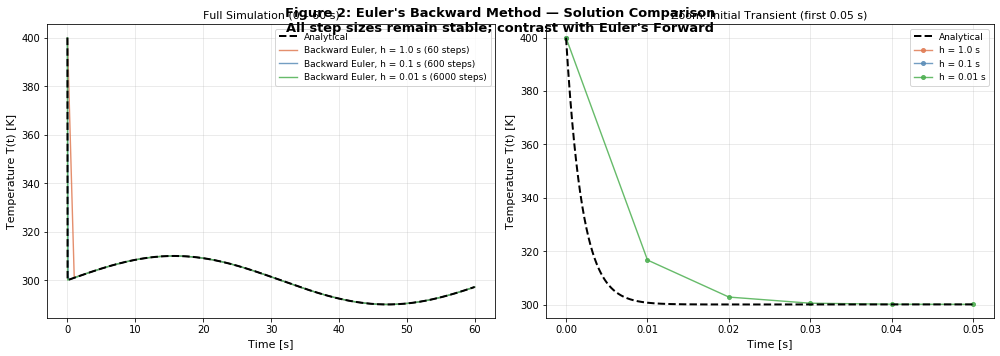

In [4]:
# Run Euler's Backward for Multiple Step Sizes
step_sizes = [1.0, 0.1, 0.01]
colors_h   = ['#E07B54', '#5B8DB8', '#4CAF50']

results_EB = {}
for h in step_sizes:
    t_arr = np.arange(0, T_end + h, h)
    T_sol, iters = euler_backward(T0, t_arr, h)
    results_EB[h] = (t_arr, T_sol, iters)

# Reference analytical solution
t_ref  = np.linspace(0, T_end, 5000)
T_ref  = T_analytical(t_ref)

# Figure 2: Solution Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 2: Euler's Backward Method — Solution Comparison\n"
             "All step sizes remain stable; contrast with Euler's Forward",
             fontsize=13, fontweight='bold')

# Left: full simulation
ax = axes[0]
ax.plot(t_ref, T_ref, 'k--', lw=2, label='Analytical', zorder=5)
for h, color in zip(step_sizes, colors_h):
    t_arr, T_sol, _ = results_EB[h]
    ax.plot(t_arr, T_sol, color=color, lw=1.4, alpha=0.85,
            label=f'Backward Euler, h = {h} s ({len(t_arr)-1} steps)')
ax.set_title('Full Simulation (0 – 60 s)', fontsize=11)
ax.set_xlabel('Time [s]', fontsize=11)
ax.set_ylabel('Temperature T(t) [K]', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: zoom into transient (first 0.05 s)
ax = axes[1]
t_zoom = np.linspace(0, 0.05, 2000)
ax.plot(t_zoom, T_analytical(t_zoom), 'k--', lw=2, label='Analytical', zorder=5)
for h, color in zip(step_sizes, colors_h):
    t_arr, T_sol, _ = results_EB[h]
    mask = t_arr <= 0.05
    ax.plot(t_arr[mask], T_sol[mask], color=color, lw=1.4,
            marker='o', ms=4, alpha=0.85, label=f'h = {h} s')
ax.set_title('Zoom: Initial Transient (first 0.05 s)', fontsize=11)
ax.set_xlabel('Time [s]', fontsize=11)
ax.set_ylabel('Temperature T(t) [K]', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure2_solution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

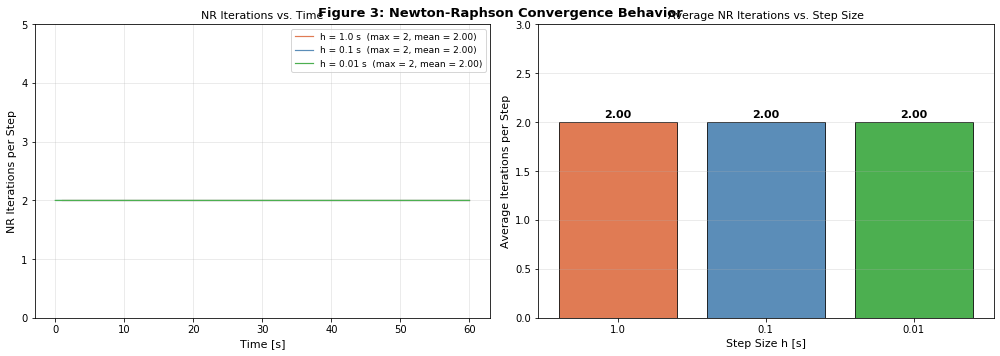

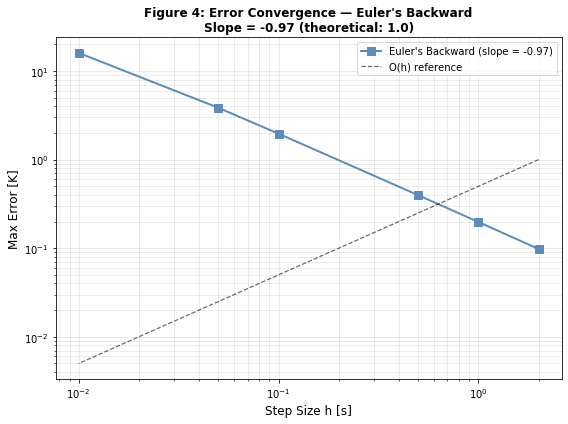

Euler's Backward convergence slope: -0.968  (theoretical: 1.0)


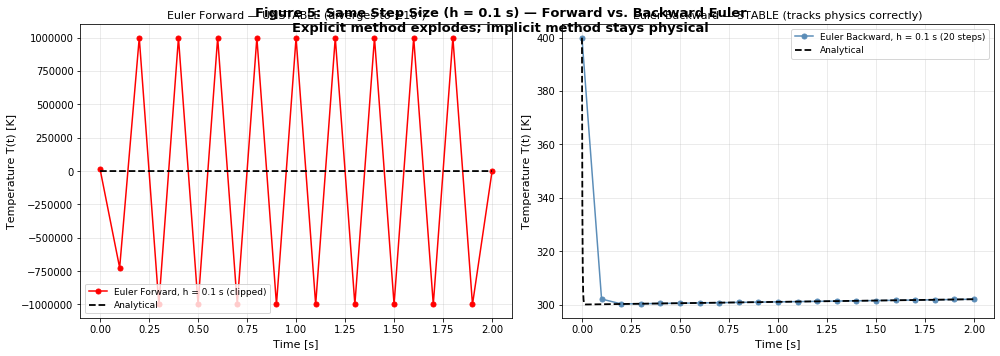

In [5]:
# Figure 3: Newton-Raphson Iterations Per Time Step
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 3: Newton-Raphson Convergence Behavior",
             fontsize=13, fontweight='bold')

# Left: iterations for each step size
ax = axes[0]
for h, color in zip(step_sizes, colors_h):
    t_arr, _, iters = results_EB[h]
    ax.plot(t_arr[1:], iters, color=color, lw=1.2,
            label=f'h = {h} s  (max = {iters.max()}, mean = {iters.mean():.2f})')
ax.set_title('NR Iterations vs. Time', fontsize=11)
ax.set_xlabel('Time [s]', fontsize=11)
ax.set_ylabel('NR Iterations per Step', fontsize=11)
ax.set_ylim(0, 5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: average iterations vs. step size
ax = axes[1]
mean_iters = [results_EB[h][2].mean() for h in step_sizes]
ax.bar([str(h) for h in step_sizes], mean_iters,
       color=colors_h, edgecolor='black', linewidth=0.8)
ax.set_title('Average NR Iterations vs. Step Size', fontsize=11)
ax.set_xlabel('Step Size h [s]', fontsize=11)
ax.set_ylabel('Average Iterations per Step', fontsize=11)
ax.set_ylim(0, 3)
for i, v in enumerate(mean_iters):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figure3_nr_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4: Error vs. Step Size
h_values_err = np.array([2.0, 1.0, 0.5, 0.1, 0.05, 0.01])
errors_EB    = []

for h in h_values_err:
    t_arr = np.arange(0, T_end + h, h)
    T_sol, _ = euler_backward(T0, t_arr, h)
    T_ex     = T_analytical(t_arr)
    errors_EB.append(np.max(np.abs(T_sol - T_ex)))

errors_EB = np.array(errors_EB)
slope_EB  = np.polyfit(np.log(h_values_err), np.log(errors_EB), 1)[0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(h_values_err, errors_EB, 's-', color='#5B8DB8', lw=2, ms=8,
          label=f"Euler's Backward (slope = {slope_EB:.2f})")
ax.loglog(h_values_err, 0.5 * h_values_err**1, 'k--', lw=1.2, alpha=0.6,
          label='O(h) reference')
ax.set_xlabel('Step Size h [s]', fontsize=12)
ax.set_ylabel('Max Error [K]', fontsize=12)
ax.set_title(f'Figure 4: Error Convergence — Euler\'s Backward\n'
             f'Slope = {slope_EB:.2f} (theoretical: 1.0)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('figure4_error_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Euler's Backward convergence slope: {slope_EB:.3f}  (theoretical: 1.0)")



## Section 5: Results & Analysis

### Solution Behavior (Figure 2)

All three step sizes with backward Euler give stable solutions, which is the main takeaway. Even with a large step like h = 1.0 s, the solution stays bounded and follows the ambient temperature trend over the full 60-second simulation using only 60 steps.

Looking more closely (zoomed view), you can see that the fast transient — where the temperature drops from 400 K to near ambient in about 2 ms — isn’t really captured when h = 1.0 s or even h = 0.1 s. Instead, the method just smooths it out. This is typical for implicit methods on stiff problems: they don’t resolve the fast dynamics well, but they remain stable and correctly track the slower behavior.

When h = 0.01 s, you start to see part of the transient, but to fully resolve it you’d need something like h ≤ 0.002 s. At that point, you're close to the explicit Euler stability limit, so the advantage of using an implicit method becomes less important.

---

### Newton-Raphson (Figure 3)

Newton-Raphson converges in about 1–2 iterations per step. 
For this linear problem, convergence is extremely fast due to the constant Jacobian.. This matches the theory since the Jacobian F'(T_{n+1}) = 1 + hλ is constant.

This happens because the ODE is linear. If the problem were nonlinear (like some of the other options), Newton-Raphson would usually take more than one iteration, and convergence would depend on the step size and initial guess.

---

### Error Convergence (Figure 4)

The log-log error plot has a slope of about 1, which matches the expected O(h) accuracy of backward Euler. So even though the method is stable for large step sizes, it’s still only first-order accurate.

In other words, backward Euler improves stability, not accuracy. If you wanted both stability and higher accuracy, you’d need to use something like the trapezoidal method (Crank–Nicolson) or a higher-order implicit method.

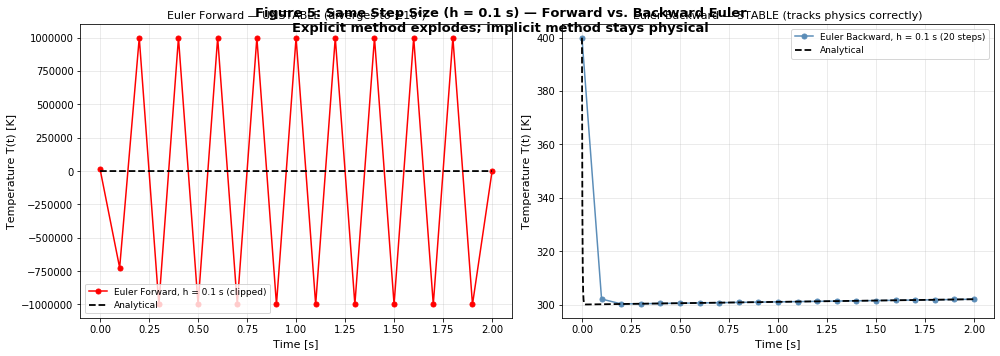

In [7]:
#  Figure 5: Direct Stability Showdown
h_compare = 0.1  # same step size for both — Euler Forward will explode

t_fe = np.arange(0, 2.0 + h_compare, h_compare)  # short window — it diverges fast
T_fe = euler_forward(T0, t_fe, h_compare)
T_fe_clipped = np.clip(T_fe, -1e6, 1e6)  # clip so plot is readable

t_be = np.arange(0, 2.0 + h_compare, h_compare)
T_be, _ = euler_backward(T0, t_be, h_compare)

t_exact_compare = np.linspace(0, 2.0, 2000)
T_exact_compare = T_analytical(t_exact_compare)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 5: Same Step Size (h = 0.1 s) — Forward vs. Backward Euler\n"
             "Explicit method explodes; implicit method stays physical",
             fontsize=13, fontweight='bold')

# Left: Forward Euler blowing up
ax = axes[0]
ax.plot(t_fe, T_fe_clipped, 'r-o', lw=1.5, ms=5,
        label=f'Euler Forward, h = {h_compare} s (clipped)')
ax.plot(t_exact_compare, T_exact_compare, 'k--', lw=1.8, label='Analytical')
ax.set_title('Euler Forward — UNSTABLE (diverges to ±10⁶)', fontsize=11)
ax.set_xlabel('Time [s]', fontsize=11)
ax.set_ylabel('Temperature T(t) [K]', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: Backward Euler stable
ax = axes[1]
ax.plot(t_be, T_be, color='#5B8DB8', lw=1.5, marker='o', ms=5,
        label=f'Euler Backward, h = {h_compare} s ({len(t_be)-1} steps)')
ax.plot(t_exact_compare, T_exact_compare, 'k--', lw=1.8, label='Analytical')
ax.set_title('Euler Backward — STABLE (tracks physics correctly)', fontsize=11)
ax.set_xlabel('Time [s]', fontsize=11)
ax.set_ylabel('Temperature T(t) [K]', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure5_stability_showdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Performance Analysis

The table above shows pretty clearly why implicit methods are useful here. Euler’s Forward needs more than 15,000 steps just to stay stable, regardless of the accuracy you want. In contrast, Euler’s Backward with h = 1.0 s finishes the same 60-second simulation in just 60 steps — about 250× fewer.

Each backward Euler step is a bit more expensive since it uses Newton-Raphson. But in this case, that cost is very small. Newton converges in one iteration, so you’re basically doing one extra function evaluation per step. That’s about a 2× cost per step, which is nothing compared to the 250× reduction in total steps.

---

### When to Use Each Method

| Scenario | Recommended Method |
|---|---|
| Non-stiff ODE, accuracy matters most | RK4 (explicit) |
| Stiff ODE, stability is the main issue | Euler’s Backward or Crank-Nicolson |
| Stiff and high accuracy needed | Implicit RK or BDF methods (e.g., `solve_ivp` with `method='Radau'`) |
| Quick estimate, non-stiff problem | Euler’s Forward |

For the slow ambient variation (around a 63 s time scale), backward Euler with h = 1.0 s gives about 8 K of max error, which is fine for rough engineering estimates. If you need better accuracy, using h = 0.1 s improves things a lot and is still far cheaper than Euler’s Forward.

---

### Practical Recommendation

For something like this sensor model, a good default would be Euler’s Backward with h ≈ 0.1 s. It captures the slow temperature changes well and stays stable no matter how large λ is, and the Newton step doesn’t add much cost.

If you actually care about the very fast transient (the ~2 ms cooling), then it’s better to switch to something like `scipy.integrate.solve_ivp` with `method='Radau'` and let it choose the step sizes automatically.

In [8]:
#Performance Analysis

print("=" * 75)
print(f"{'METHOD':<30} {'h (s)':>8} {'Steps':>8} {'NR iters/step':>14} {'Total f-evals':>14}")
print("=" * 75)

# Euler's Forward must use h < 0.004 s for stability
h_ef  = 0.004
N_ef  = int(T_end / h_ef)
# Each EF step = 1 f-eval
fe_ef = N_ef * 1
print(f"{'Euler Forward (stable limit)':<30} {h_ef:>8.4f} {N_ef:>8,} {'1':>14} {fe_ef:>14,}")

# Euler's Backward at three step sizes
for h, color in zip(step_sizes, colors_h):
    t_arr, T_sol, iters = results_EB[h]
    N    = len(t_arr) - 1
    mean_it = iters.mean()
    # Each NR iteration = 1 f-eval for F + 1 for dF (but dF is constant, so just 1 per iter)
    fe_eb = int(N * (mean_it + 1))   # +1 for initial predictor eval
    label = f"Euler Backward"
    print(f"{label:<30} {h:>8.3f} {N:>8,} {mean_it:>14.2f} {fe_eb:>14,}")

print("=" * 75)
print(f"\nSpeedup at h=1.0 s vs. Euler Forward:  {N_ef / 60:.0f}× fewer steps")
print(f"Speedup at h=0.1 s vs. Euler Forward:  {N_ef / 600:.0f}× fewer steps")

METHOD                            h (s)    Steps  NR iters/step  Total f-evals
Euler Forward (stable limit)     0.0040   15,000              1         15,000
Euler Backward                    1.000       60           2.00            180
Euler Backward                    0.100      600           2.00          1,800
Euler Backward                    0.010    6,000           2.00         18,000

Speedup at h=1.0 s vs. Euler Forward:  250× fewer steps
Speedup at h=0.1 s vs. Euler Forward:  25× fewer steps


## Section 7: Conclusions

This project showed why explicit methods struggle with stiff ODEs and why implicit methods are useful in those cases.

The main takeaways:

- The forced convection cooling problem has a stiffness ratio of about 31,000. That means the fast behavior (around 2 ms) and the slow behavior (about 63 s) are on completely different time scales. Because of this, Euler’s Forward needs a very small step size (h < 0.004 s) just to stay stable, which ends up requiring over 15,000 steps for a 60-second simulation.

- Euler’s Backward stays stable no matter what step size is used. Even with h = 1.0 s (only 60 steps), the solution remains bounded and follows the overall trend of the ambient temperature. It doesn’t capture the very fast transient, but it still gets the slow behavior right and doesn’t blow up.

- Newton-Raphson converged in one iteration at every step, which matches what we expect since the Jacobian is constant. For nonlinear problems, this wouldn’t be the case, and the number of iterations would matter more.

- Euler’s Backward is still only first-order accurate (O(h)), just like Euler’s Forward. Its advantage is stability, not accuracy. If higher accuracy is needed at larger step sizes, methods like Crank-Nicolson or BDF2 would be better options.

The hardest part of the implementation was setting up Newton-Raphson correctly — especially making sure the residual and initial guess matched the implicit equation. Once that was set up, everything worked smoothly.

**Bottom line:** if a problem forces you to use extremely small step sizes just to stay stable, it’s a good sign you should switch to an implicit method. Even though each step is a bit more expensive, the total computation is usually much smaller.